In [5]:
import sys
sys.path.append("tools")
import pandas as pd
import matplotlib.pyplot as plt
from analyse_crossover import load_results, aggregate_gpu, aggregate_cpu

In [6]:
gpu_df = load_results("../ground_truth/gpu_bench_results.csv")
cpu_df = load_results("../ground_truth/cpu_bench_results.csv")
gpu_agg = aggregate_gpu(gpu_df)
cpu_agg = aggregate_cpu(cpu_df)
ensemble_sizes = sorted(gpu_agg["ensemble_size"].unique())

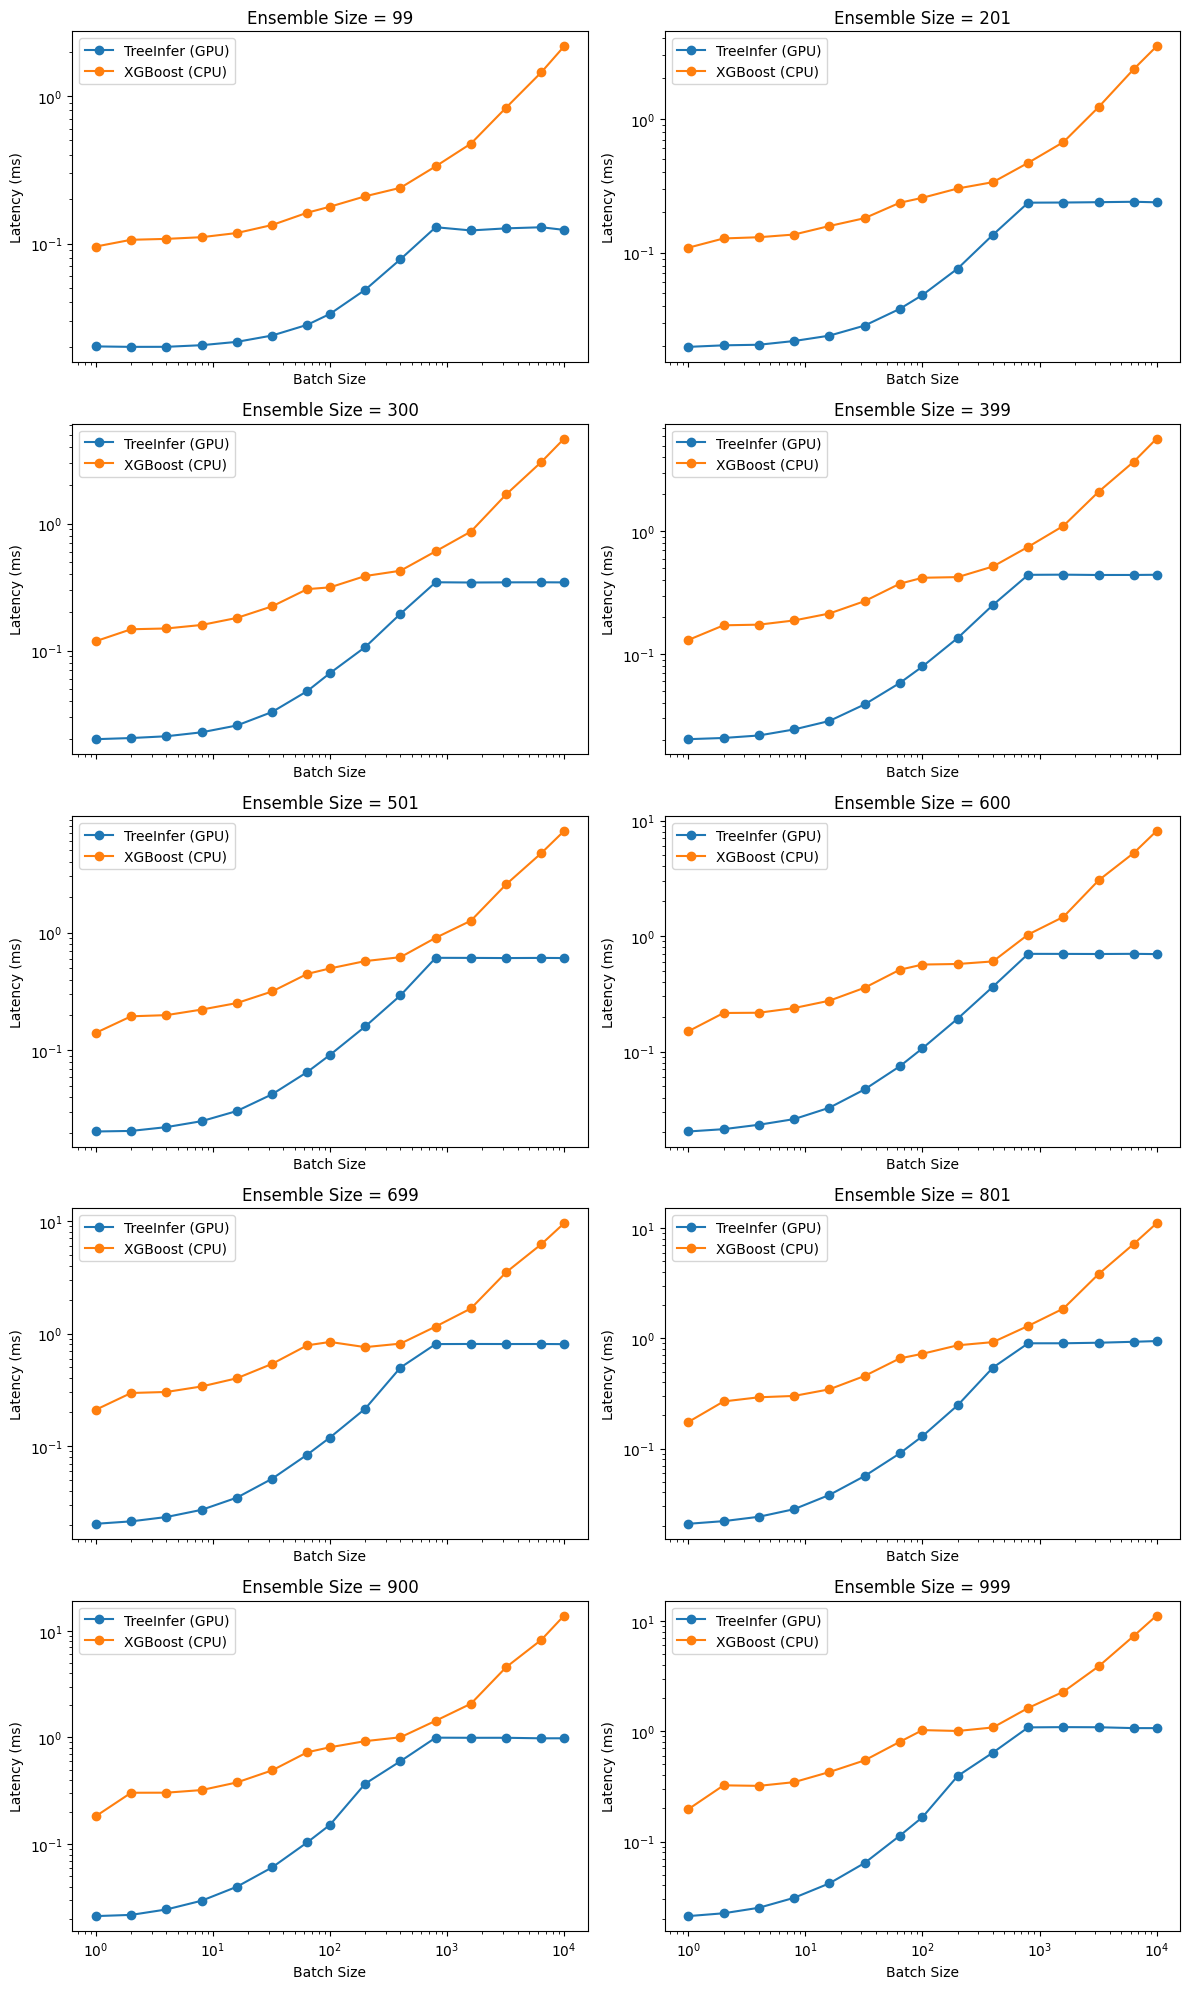

In [10]:
fig, axes = plt.subplots(5, 2, figsize=(12, 20), sharex=True)
axes = axes.flatten()
for ax, ensemble_size in zip(axes, ensemble_sizes):
    gpu_sub = gpu_agg[gpu_agg["ensemble_size"] == ensemble_size].sort_values("batch_size")
    cpu_sub = cpu_agg[cpu_agg["ensemble_size"] == ensemble_size].sort_values("batch_size")
    ax.plot(gpu_sub["batch_size"], gpu_sub["gpu_total_ms"], label="TreeInfer (GPU)", marker="o")
    ax.plot(cpu_sub["batch_size"], cpu_sub["predict_ms"], label="XGBoost (CPU)", marker="o")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Ensemble Size = {ensemble_size}")
    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Latency (ms)")
    ax.legend()

plt.tight_layout()
plt.savefig("../plots/gpu_vs_cpu_latency.png") 
plt.show()

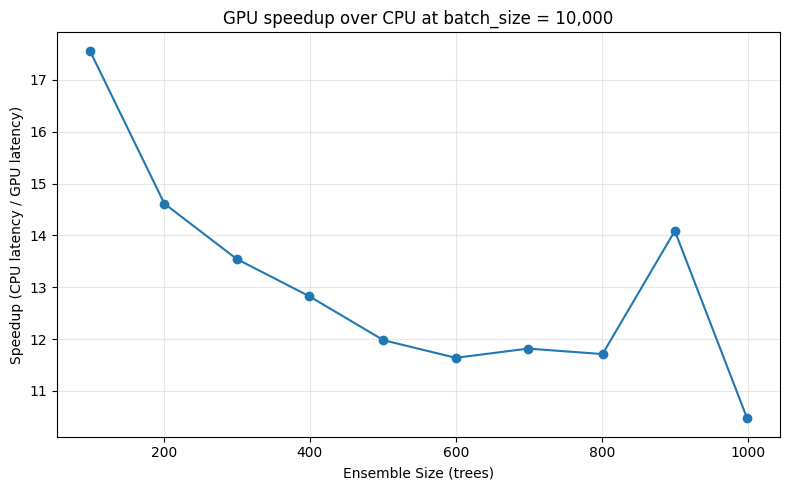

In [11]:
gpu_at_10k = gpu_agg[gpu_agg["batch_size"] == 10000].sort_values("ensemble_size")
cpu_at_10k = cpu_agg[cpu_agg["batch_size"] == 10000].sort_values("ensemble_size")

merged_10k = pd.merge(gpu_at_10k, cpu_at_10k, on="ensemble_size")
merged_10k["speedup"] = merged_10k["predict_ms"] / merged_10k["gpu_total_ms"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(merged_10k["ensemble_size"], merged_10k["speedup"], marker="o")
ax.set_xlabel("Ensemble Size (trees)")
ax.set_ylabel("Speedup (CPU latency / GPU latency)")
ax.set_title("GPU speedup over CPU at batch_size = 10,000")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/speedup_vs_ensemble_size.png")
plt.show()